# Huawei AI Certification: AI Final Exam Lab
## Handwritten Digit Recognition (MNIST)
**Objective:** Master the basic process of TensorFlow computing and build neural networks to classify MNIST hand-written digits. We will evaluate a Deep Neural Network (DNN) against a Convolutional Neural Network (CNN) architecture.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, optimizers
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.models import Sequential, load_model

# Ensure inline plotting
%matplotlib inline

I0000 00:00:1777685359.528055 2702417 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777685359.587772 2702417 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777685361.442989 2702417 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 1. Dataset Acquisition
Load the MNIST dataset natively into training and test variables, and construct one-hot encoded tensors for classification.

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
print("First 5 labels:", y_train[:5])
print("x_train shape:", x_train.shape, "y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape, "y_test shape :", y_test.shape)

n_classes = 10
y_train_oh = keras.utils.to_categorical(y_train, n_classes)
y_test_oh = keras.utils.to_categorical(y_test, n_classes)
print("One-hot sample:\n", y_train_oh[:5])

First 5 labels: [5 0 4 1 9]
x_train shape: (60000, 28, 28) y_train shape: (60000,)
x_test shape : (10000, 28, 28) y_test shape : (10000,)
One-hot sample:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


### 2. Data Visualization
Extract and plot exactly how the computer natively parses the numeric pixel grids.

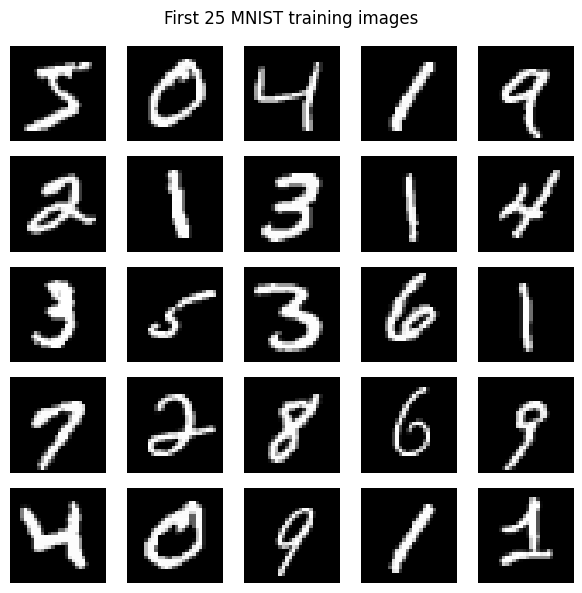

In [3]:
plt.figure(figsize=(6, 6))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.suptitle("First 25 MNIST training images")
plt.tight_layout()
plt.show()

### 3. Deep Neural Network (DNN) Construction
We flat-pack the 28x28 matrices into 1D (784) tensors, and map them linearly across multiple dense feed-forward node layers.

In [4]:
# Preprocess for DNN (flatten + normalize)
X_train_dnn = x_train.reshape(60000, 784).astype("float32") / 255.0
X_test_dnn = x_test.reshape(10000, 784).astype("float32") / 255.0

dnn = Sequential([
    Dense(512, activation="relu", input_dim=784),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(n_classes, activation="softmax"),
])
dnn.summary()

dnn.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=optimizers.Adam(0.001),
    metrics=["accuracy"],
)

dnn_history = dnn.fit(
    X_train_dnn, y_train_oh,
    batch_size=128, epochs=10, verbose=2,
    validation_data=(X_test_dnn, y_test_oh),
)

dnn_score = dnn.evaluate(X_test_dnn, y_test_oh, verbose=0)
print("DNN Test loss:", dnn_score[0])
print("DNN Test accuracy:", dnn_score[1])

/home/ansinitro/AITU/ai-nn/midterm/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777685363.240408 2702417 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777685363.240779 2702502 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777685363.255852 2702417 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you wo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


W0000 00:00:1777685363.614474 2702417 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 - 4s - 10ms/step - accuracy: 0.9319 - loss: 0.2288 - val_accuracy: 0.9677 - val_loss: 0.1055
Epoch 2/10
469/469 - 3s - 6ms/step - accuracy: 0.9737 - loss: 0.0863 - val_accuracy: 0.9723 - val_loss: 0.0853
Epoch 3/10
469/469 - 3s - 6ms/step - accuracy: 0.9827 - loss: 0.0555 - val_accuracy: 0.9770 - val_loss: 0.0739
Epoch 4/10
469/469 - 3s - 6ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.9724 - val_loss: 0.0953
Epoch 5/10
469/469 - 3s - 6ms/step - accuracy: 0.9893 - loss: 0.0317 - val_accuracy: 0.9754 - val_loss: 0.0865
Epoch 6/10
469/469 - 3s - 7ms/step - accuracy: 0.9912 - loss: 0.0272 - val_accuracy: 0.9789 - val_loss: 0.0750
Epoch 7/10
469/469 - 3s - 7ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9789 - val_loss: 0.0769
Epoch 8/10
469/469 - 4s - 8ms/step - accuracy: 0.9928 - loss: 0.0217 - val_accuracy: 0.9798 - val_loss: 0.0792
Epoch 9/10
469/469 - 3s - 7ms/step - accuracy: 0.9940 - loss: 0.0179 - val_accuracy: 0.9780 - val_loss: 0.0850
Epoch 10/10

### 4. Convolutional Neural Network (CNN) Construction
We preserve the spatial 2D matrix shape, allowing the CNN kernels to systematically extract positional hierarchies and edge gradients natively, maximizing feature recognition accuracy!

In [5]:
X_train_cnn = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test_cnn = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

cnn = Sequential()
cnn.add(Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu", input_shape=(28, 28, 1)))
cnn.add(MaxPool2D(pool_size=(2, 2)))
cnn.add(Conv2D(64, kernel_size=(3, 3), padding="valid", activation="relu"))
cnn.add(MaxPool2D(pool_size=(2, 2)))
cnn.add(Dropout(0.25))
cnn.add(Flatten())
cnn.add(Dense(128, activation="relu"))
cnn.add(Dropout(0.5))
cnn.add(Dense(n_classes, activation="softmax"))
cnn.summary()

cnn.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

cnn_history = cnn.fit(
    X_train_cnn, y_train_oh,
    epochs=5, batch_size=128, verbose=2,
    validation_data=(X_test_cnn, y_test_oh),
)

cnn_score = cnn.evaluate(X_test_cnn, y_test_oh, verbose=0)
print("CNN Test Loss:", cnn_score[0])
print("CNN Test Accuracy:", cnn_score[1])

/home/ansinitro/AITU/ai-nn/midterm/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,146 (1.20 MB)

 Trainable params: 315,146 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


W0000 00:00:1777685397.829101 2702417 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 - 21s - 45ms/step - accuracy: 0.9106 - loss: 0.2942 - val_accuracy: 0.9825 - val_loss: 0.0550
Epoch 2/5
469/469 - 17s - 37ms/step - accuracy: 0.9717 - loss: 0.0955 - val_accuracy: 0.9878 - val_loss: 0.0369
Epoch 3/5
469/469 - 18s - 38ms/step - accuracy: 0.9784 - loss: 0.0724 - val_accuracy: 0.9897 - val_loss: 0.0321
Epoch 4/5
469/469 - 16s - 35ms/step - accuracy: 0.9821 - loss: 0.0607 - val_accuracy: 0.9892 - val_loss: 0.0312
Epoch 5/5
469/469 - 16s - 34ms/step - accuracy: 0.9844 - loss: 0.0509 - val_accuracy: 0.9915 - val_loss: 0.0260
CNN Test Loss: 0.026009762659668922
CNN Test Accuracy: 0.9915000200271606


### 5. Architectural Evaluation and Training Validation Curves

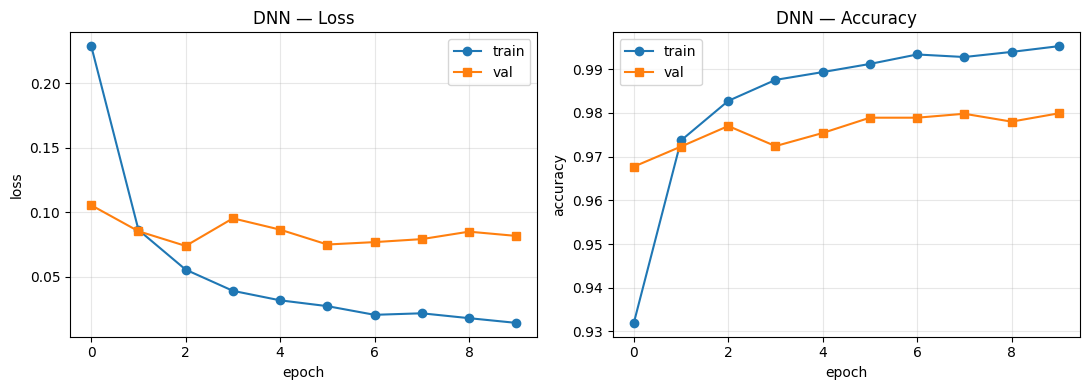

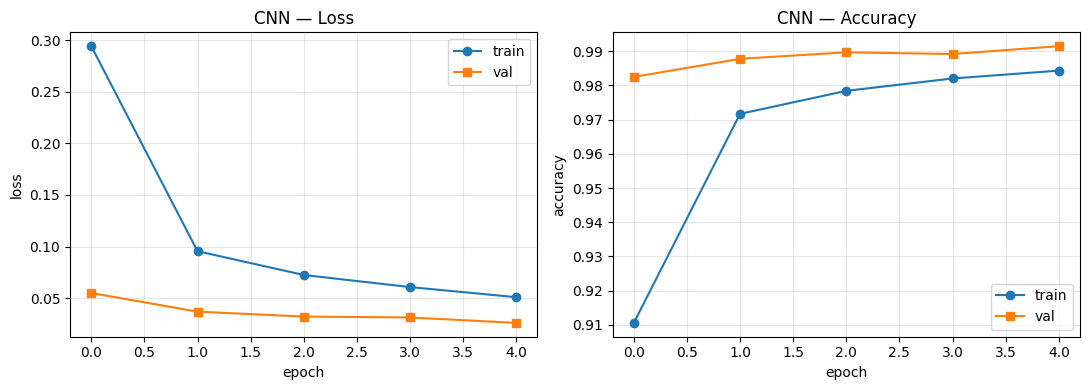

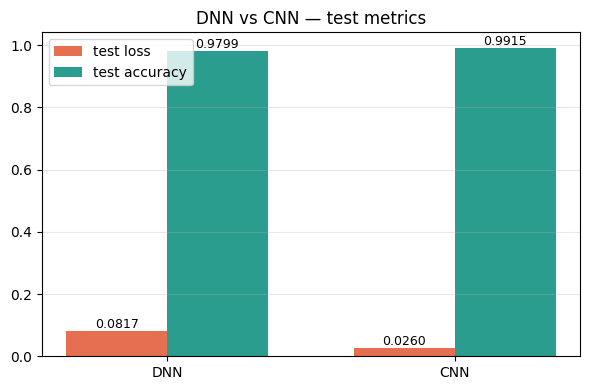

In [6]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], "o-", label="train")
    axes[0].plot(history.history["val_loss"], "s-", label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history["accuracy"], "o-", label="train")
    axes[1].plot(history.history["val_accuracy"], "s-", label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(dnn_history, "DNN")
plot_history(cnn_history, "CNN")

# ---------- Model comparison bar chart ----------
fig, ax = plt.subplots(figsize=(6, 4))
names = ["DNN", "CNN"]
losses = [dnn_score[0], cnn_score[0]]
accs = [dnn_score[1], cnn_score[1]]
xs = np.arange(len(names))
w = 0.35
b1 = ax.bar(xs - w / 2, losses, w, label="test loss", color="#e76f51")
b2 = ax.bar(xs + w / 2, accs, w, label="test accuracy", color="#2a9d8f")
ax.set_xticks(xs); ax.set_xticklabels(names)
ax.set_title("DNN vs CNN — test metrics")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for b in (*b1, *b2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 6. Confusion Matrices and Predictions
Finally, evaluating the exact false-positive failure modes between architectures natively.

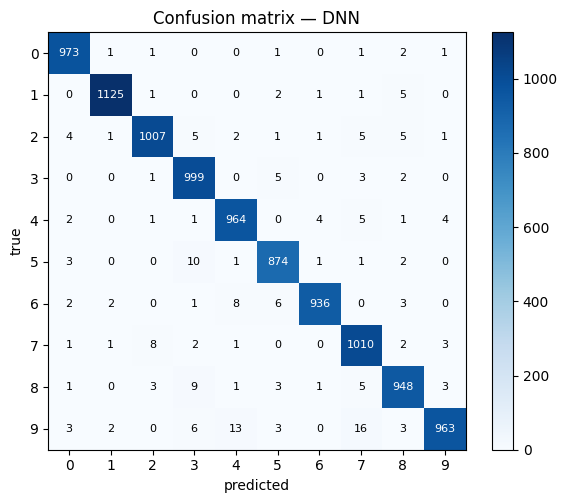

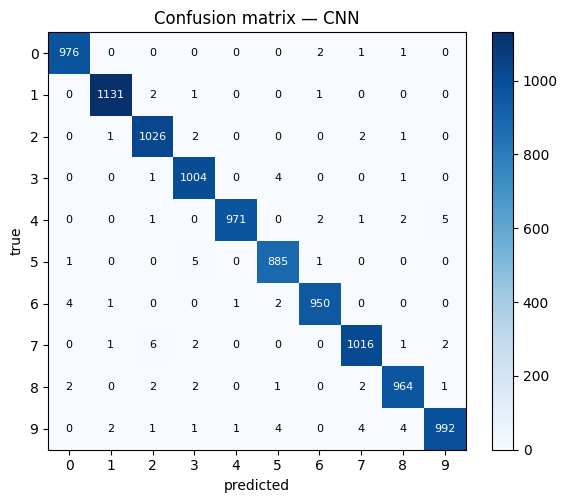

In [7]:
def plot_confusion(model, X, y_true, title):
    probs = model.predict(X, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion matrix — {title}")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    fig.colorbar(im, ax=ax)
    thresh = cm.max() / 2.0
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8, color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()
    return y_pred

dnn_pred = plot_confusion(dnn, X_test_dnn, y_test, "DNN")
cnn_pred = plot_confusion(cnn, X_test_cnn, y_test, "CNN")

### Model Deployment Simulation
Running a mock inference pipeline on 20 raw tensor inputs to determine deployment readiness.

Prediction results of the first 20 images:


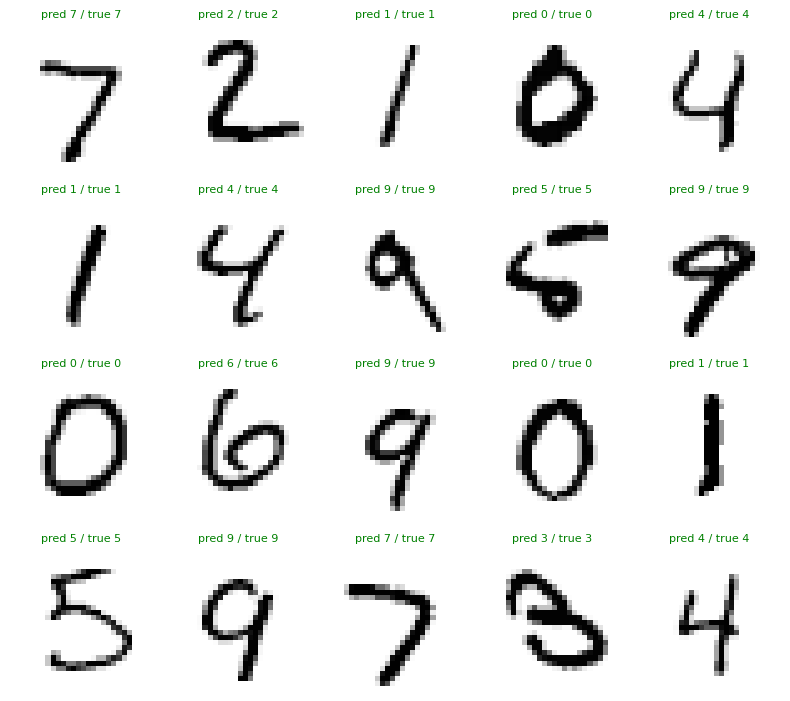

In [8]:
def res_visual(n):
    probs = cnn.predict(X_test_cnn[0:n], verbose=0)
    final_opt_a = np.argmax(probs, axis=1)

    fig, ax = plt.subplots(nrows=int(n / 5), ncols=5, figsize=(8, 1.8 * (n // 5)))
    ax = ax.flatten()
    print(f"Prediction results of the first {n} images:")
    for i in range(n):
        img = X_test_cnn[i].reshape((28, 28))
        ax[i].imshow(img, cmap="Greys")
        ok = final_opt_a[i] == y_test[i]
        ax[i].set_title(f"pred {final_opt_a[i]} / true {y_test[i]}", fontsize=8, color="green" if ok else "red")
        ax[i].axis("off")
    plt.tight_layout()
    plt.show()

res_visual(20)